In [12]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
from scipy.optimize import least_squares

sys.path.insert(0, str(Path("../../nogse_pipeline/src")))
from models.model_fitting import M_ogse_mixed_offset
from plotting.publication.tc_param_vars import _roi_color_map, DEFAULT_BRAIN_MARKERS

In [13]:
MASTER_PATH  = Path("../../analysis/brains/ogse_experiments/master.long.parquet")
OUT_DIR      = Path("../../analysis/brains/ogse_experiments/mixed_fits")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DIRECTIONS  = ["tra", "long"]
N_LIST      = [4, 8, 12]
TD_LIST     = [90.0, 120.0, 143.4, 210.0]      # None → all td; list of floats → e.g. [76.0, 90.0, 120.0]
ROI_LIST    = ["AntCC", "MidAntCC", "CentralCC", "MidPostCC", "PostCC", "Left-Lateral-Ventricle", "Right-Lateral-Ventricle"]      # None → all ROIs; list of strings → e.g. [ "PostCC", "Left-Lateral-Ventricle"]
D0_FIXED    = 3.2e-12   # m²/ms, fixed
TC_FIXED    = None      # None → tc is fitted; float → tc is pinned [ms]
ALPHA_FIXED = 0         # None → alpha is fitted; float → alpha is pinned
M0_FIXED    = None      # None → M0 is fitted; float → M0 is pinned (e.g. 1.0 to normalise)
C_FIXED     = None      # None → C is fitted; float → C is pinned
RN_FIXED    = 60.0      # None → RN is fitted; float → RN is pinned

In [14]:
df = pd.read_parquet(MASTER_PATH)

data = df[
    (df.row_kind == "signal_rotated") &
    (df.direction.isin(DIRECTIONS)) &
    (df.N.isin(N_LIST)) &
    (df.stat == "avg")
].copy()

data["G_eff"] = data.g_thorsten * data.grad_correction_factor

if TD_LIST is not None:
    data = data[data.td_ms.isin(TD_LIST)]
if ROI_LIST is not None:
    data = data[data.roi.isin(ROI_LIST)]

print(f"Rows loaded: {len(data)}")
print("Groups (subj, roi, dir):", data.groupby(["subj", "roi", "direction"]).ngroups)
data[["subj", "roi", "direction", "td_ms", "N", "G_eff", "value"]]

Rows loaded: 5544
Groups (subj, roi, dir): 42


,subj,roi,direction,td_ms,N,G_eff,value
5302,BRAIN,AntCC,tra,90.0,4,0.000000,250.168675
5303,BRAIN,AntCC,tra,90.0,4,6.213986,244.684694
5304,BRAIN,AntCC,tra,90.0,4,12.427971,228.825266
5305,BRAIN,AntCC,tra,90.0,4,18.641957,214.273122
5306,BRAIN,AntCC,tra,90.0,4,24.855943,194.742588
...,...,...,...,...,...,...,...
183827,MBBL,Right-Lateral-Ventricle,long,210.0,12,39.498888,245.681774
183828,MBBL,Right-Lateral-Ventricle,long,210.0,12,46.082037,138.714412
183829,MBBL,Right-Lateral-Ventricle,long,210.0,12,52.665185,78.337036
183830,MBBL,Right-Lateral-Ventricle,long,210.0,12,59.248333,52.800976


In [15]:
def _unpack(params):
    """Extract (tc, alpha, M0, C, RN) from the optimizer parameter vector."""
    idx = 0
    if TC_FIXED is None:
        tc = np.exp(params[idx]); idx += 1
    else:
        tc = TC_FIXED
    if ALPHA_FIXED is None:
        alpha = params[idx]; idx += 1
    else:
        alpha = ALPHA_FIXED
    if M0_FIXED is None:
        M0 = params[idx]; idx += 1
    else:
        M0 = M0_FIXED
    if C_FIXED is None:
        C = params[idx]; idx += 1
    else:
        C = C_FIXED
    if RN_FIXED is None:
        RN = params[idx]
    else:
        RN = RN_FIXED
    return tc, alpha, M0, C, RN


def fit_curve(td, N, G, y):
    """Fit M_ogse_mixed_offset for ONE (td, N) curve independently."""

    def residuals(params):
        tc, alpha, M0, C, RN = _unpack(params)
        with np.errstate(over="ignore", invalid="ignore"):
            y_hat = M_ogse_mixed_offset(
                td, G, N, td / N, tc, alpha, M0, D0_FIXED, C, RN
            )
        out = y_hat - y
        return np.where(np.isfinite(out), out, 1e6)

    M0_init = float(y.max())
    x0 = []; lower = []; upper = []
    if TC_FIXED is None:
        x0 += [np.log(1.0)];  lower += [np.log(0.5)];  upper += [np.log(100.0)]
    if ALPHA_FIXED is None:
        x0 += [0.5];          lower += [0.0];            upper += [1.0]
    if M0_FIXED is None:
        x0 += [M0_init];      lower += [0.0];            upper += [2000]
    if C_FIXED is None:
        x0 += [0.0];          lower += [0.0];            upper += [1000]
    if RN_FIXED is None:
        x0 += [15.0];         lower += [0.0];            upper += [np.inf]

    return least_squares(residuals, x0, bounds=(lower, upper), method="trf", max_nfev=10000)

In [16]:
rows      = []
fit_store = {}

for (subj, roi, direction), grp in data.groupby(["subj", "roi", "direction"]):
    tds = sorted(float(t) for t in grp.td_ms.unique())
    fit_store[(subj, roi, direction)] = {"tds": tds, "fits": {td: {} for td in tds}}

    for td in tds:
        sub = grp[np.isclose(grp.td_ms.astype(float), td)]
        for N in N_LIST:
            s = sub[sub.N == N].sort_values("G_eff")
            if s.empty:
                continue
            G, y = s.G_eff.values, s.value.values
            result = fit_curve(td, N, G, y)
            tc, alpha, M0, C, RN = _unpack(result.x)
            print(
                f"{subj:6s}  {roi:25s}  {direction}  td={td:5.0f} ms  N={N}  "
                f"tc={tc:.3f} ms  alpha={alpha:.3f}  cost={result.cost:.3e}"
            )
            fit_store[(subj, roi, direction)]["fits"][td][N] = dict(
                G=G, y=y, tc=tc, alpha=alpha, M0=M0, C=C, RN=RN
            )
            rows.append(dict(
                subj=subj, roi=roi, direction=direction,
                td_ms=td, N=N,
                tc_ms=tc, alpha=alpha, D0_m2ms=D0_FIXED,
                M0=M0, C=C, RN=RN,
                cost=float(result.cost), success=bool(result.success),
            ))

BRAIN   AntCC                      long  td=   90 ms  N=4  tc=14.046 ms  alpha=0.000  cost=2.163e+02
BRAIN   AntCC                      long  td=   90 ms  N=8  tc=5.127 ms  alpha=0.000  cost=7.057e+01
BRAIN   AntCC                      long  td=   90 ms  N=12  tc=100.000 ms  alpha=0.000  cost=4.366e+01
BRAIN   AntCC                      long  td=  120 ms  N=4  tc=15.875 ms  alpha=0.000  cost=8.135e+02
BRAIN   AntCC                      long  td=  120 ms  N=8  tc=9.351 ms  alpha=0.000  cost=4.549e+01
BRAIN   AntCC                      long  td=  120 ms  N=12  tc=7.258 ms  alpha=0.000  cost=4.317e+01
BRAIN   AntCC                      long  td=  143 ms  N=4  tc=100.000 ms  alpha=0.000  cost=1.286e+03
BRAIN   AntCC                      long  td=  143 ms  N=8  tc=12.885 ms  alpha=0.000  cost=2.525e+02
BRAIN   AntCC                      long  td=  143 ms  N=12  tc=8.852 ms  alpha=0.000  cost=9.556e+01
BRAIN   AntCC                      long  td=  210 ms  N=4  tc=100.000 ms  alpha=0.000  cos

In [17]:
results_df = pd.DataFrame(rows)
results_df.to_excel(OUT_DIR / "fit_results.xlsx", index=False)
print(f"Saved {len(results_df)} rows to {OUT_DIR / 'fit_results.xlsx'}")
results_df

Saved 504 rows to ../../analysis/brains/ogse_experiments/mixed_fits/fit_results.xlsx


,subj,roi,direction,td_ms,N,tc_ms,alpha,D0_m2ms,M0,C,RN,cost,success
0,BRAIN,AntCC,long,90.0,4,14.046149,0,3.200000e-12,243.922951,7.517627e-13,60.0,216.313097,True
1,BRAIN,AntCC,long,90.0,8,5.126981,0,3.200000e-12,239.613937,2.347746e-15,60.0,70.572757,True
2,BRAIN,AntCC,long,90.0,12,100.000000,0,3.200000e-12,169.719993,7.793034e+01,60.0,43.662637,True
3,BRAIN,AntCC,long,120.0,4,15.874798,0,3.200000e-12,180.208410,1.222862e-13,60.0,813.483443,True
4,BRAIN,AntCC,long,120.0,8,9.351011,0,3.200000e-12,174.101300,6.695122e-17,60.0,45.492397,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,MBBL,Right-Lateral-Ventricle,tra,143.4,8,25.015708,0,3.200000e-12,1432.115742,2.974699e-20,60.0,74.563794,True
500,MBBL,Right-Lateral-Ventricle,tra,143.4,12,19.614880,0,3.200000e-12,1431.443156,6.523490e-15,60.0,87.388535,True
501,MBBL,Right-Lateral-Ventricle,tra,210.0,4,100.000000,0,3.200000e-12,1488.751568,4.045461e-29,60.0,636.487613,True
502,MBBL,Right-Lateral-Ventricle,tra,210.0,8,63.601055,0,3.200000e-12,1481.291677,1.099440e-17,60.0,353.132850,True


In [18]:
G_plot = np.linspace(0, float(data.G_eff.max()), 300)

for (subj, roi, direction), store in fit_store.items():
    tds   = store["tds"]
    n_tds = len(tds)

    fig, axes = plt.subplots(1, n_tds, figsize=(4 * n_tds, 3.5), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, td in zip(axes, tds):
        fits_td = store["fits"][td]
        title_lines = [f"td = {td:.1f} ms"]
        for N, color in zip(N_LIST, ["C0", "C1", "C2", "C3"]):
            fit = fits_td.get(N)
            if fit is None:
                continue
            ax.scatter(fit["G"], fit["y"], color=color, s=20, zorder=3, label=f"N={N} data")
            y_hat = M_ogse_mixed_offset(
                td, G_plot, N, td / N, fit["tc"], fit["alpha"], fit["M0"], D0_FIXED, fit["C"], fit["RN"]
            )
            ax.plot(G_plot, y_hat, color=color, label=f"N={N} fit")
            title_lines.append(f"tc(N={N}) = {fit['tc']:.2f} ms")
        ax.set_title("\n".join(title_lines), fontsize=7)
        ax.set_xlabel("G_eff [mT/m]")

    axes[0].set_ylabel("value [a.u.]")
    axes[0].legend(fontsize=6)
    fig.suptitle(f"{subj}  |  {roi}  |  {direction}", fontsize=9)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"fit_{subj}_{roi}_{direction}.png", dpi=120)
    plt.close(fig)

print("Fit plots saved.")

Fit plots saved.


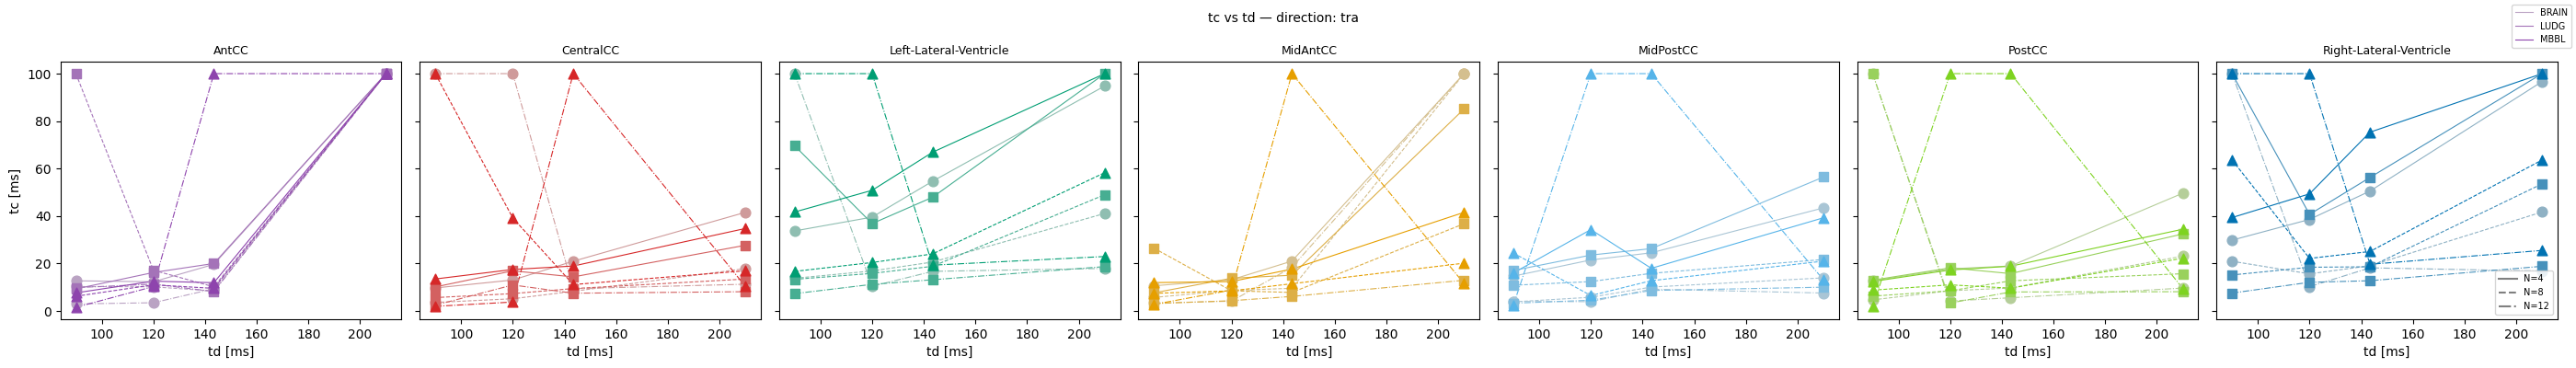

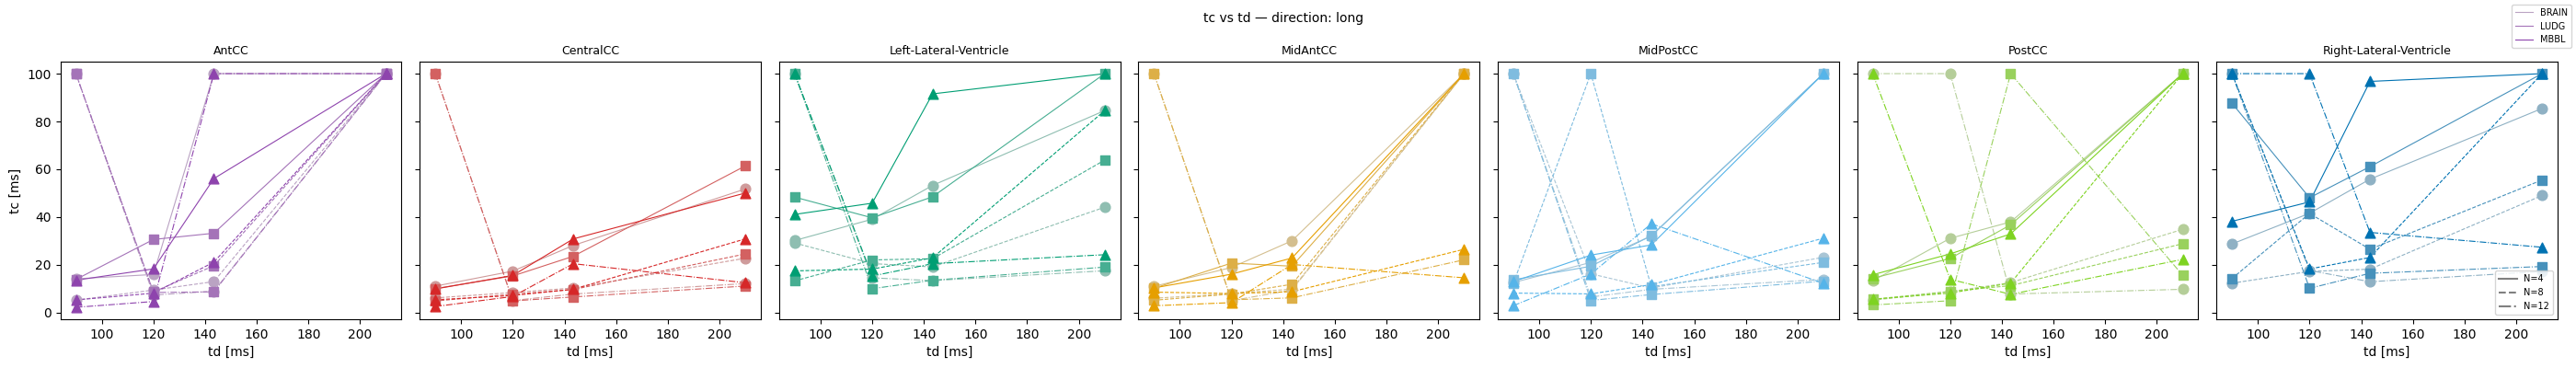

In [19]:
rois     = sorted(results_df.roi.unique())
subjects = sorted(results_df.subj.unique())
roi_colors = _roi_color_map(rois)
_N_ls        = ["-", "--", "-.", ":"]
N_linestyles = {N: ls for N, ls in zip(N_LIST, _N_ls)}

for direction in DIRECTIONS:
    sub = results_df[results_df.direction == direction]
    fig, axes = plt.subplots(1, len(rois), figsize=(4 * len(rois), 4), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, roi in zip(axes, rois):
        base_color = roi_colors[roi]
        cmap = mcolors.LinearSegmentedColormap.from_list("", ["#cccccc", base_color])
        for i, subj in enumerate(subjects):
            shade = cmap(0.3 + 0.7 * i / max(1, len(subjects) - 1))
            marker = DEFAULT_BRAIN_MARKERS[i % len(DEFAULT_BRAIN_MARKERS)]
            for N in N_LIST:
                g = (
                    sub[(sub.roi == roi) & (sub.subj == subj) & (sub.N == N)]
                    .drop_duplicates("td_ms")
                    .sort_values("td_ms")
                )
                if g.empty:
                    continue
                label = subj if N == N_LIST[0] else None
                ax.scatter(g.td_ms, g.tc_ms, color=shade, marker=marker, s=60, zorder=3)
                ax.plot(g.td_ms, g.tc_ms, color=shade, linewidth=0.8,
                        linestyle=N_linestyles[N], label=label)
        ax.set_title(roi, fontsize=9)
        ax.set_xlabel("td [ms]")

    axes[0].set_ylabel("tc [ms]")
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, fontsize=7, loc="upper right", ncol=1)
    n_handles = [mlines.Line2D([], [], color="gray", linestyle=N_linestyles[N], label=f"N={N}") for N in N_LIST]
    axes[-1].legend(handles=n_handles, fontsize=7, loc="lower right")
    fig.suptitle(f"tc vs td — direction: {direction}", fontsize=10)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"tc_vs_td_{direction}.png", dpi=120)
    plt.show()

In [20]:
for (subj, roi, direction), store in fit_store.items():
    tds   = store["tds"]
    n_tds = len(tds)

    fig, axes = plt.subplots(1, n_tds, figsize=(4 * n_tds, 3.5), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, td in zip(axes, tds):
        fits_td = store["fits"][td]
        for N, color in zip(N_LIST, ["C0", "C1", "C2", "C3"]):
            fit = fits_td.get(N)
            if fit is None:
                continue
            M0 = fit["M0"]
            ax.scatter(fit["G"], fit["y"] / M0, color=color, s=20, zorder=3, label=f"N={N} data")
            y_hat = M_ogse_mixed_offset(
                td, G_plot, N, td / N,
                fit["tc"], fit["alpha"], 1.0, D0_FIXED, fit["C"] / M0, fit["RN"] / M0
            )
            ax.plot(G_plot, y_hat, color=color, label=f"N={N} fit (M0=1)")
        ax.set_title(f"td = {td:.1f} ms", fontsize=8)
        ax.set_xlabel("G_eff [mT/m]")

    axes[0].set_ylabel("value / M0  [a.u.]")
    axes[0].legend(fontsize=6)
    fig.suptitle(
        f"{subj}  |  {roi}  |  {direction}  |  normalised (M0 = 1)",
        fontsize=9
    )
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"fit_norm_{subj}_{roi}_{direction}.png", dpi=120)
    plt.close(fig)

print("Normalised fit plots saved.")

Normalised fit plots saved.


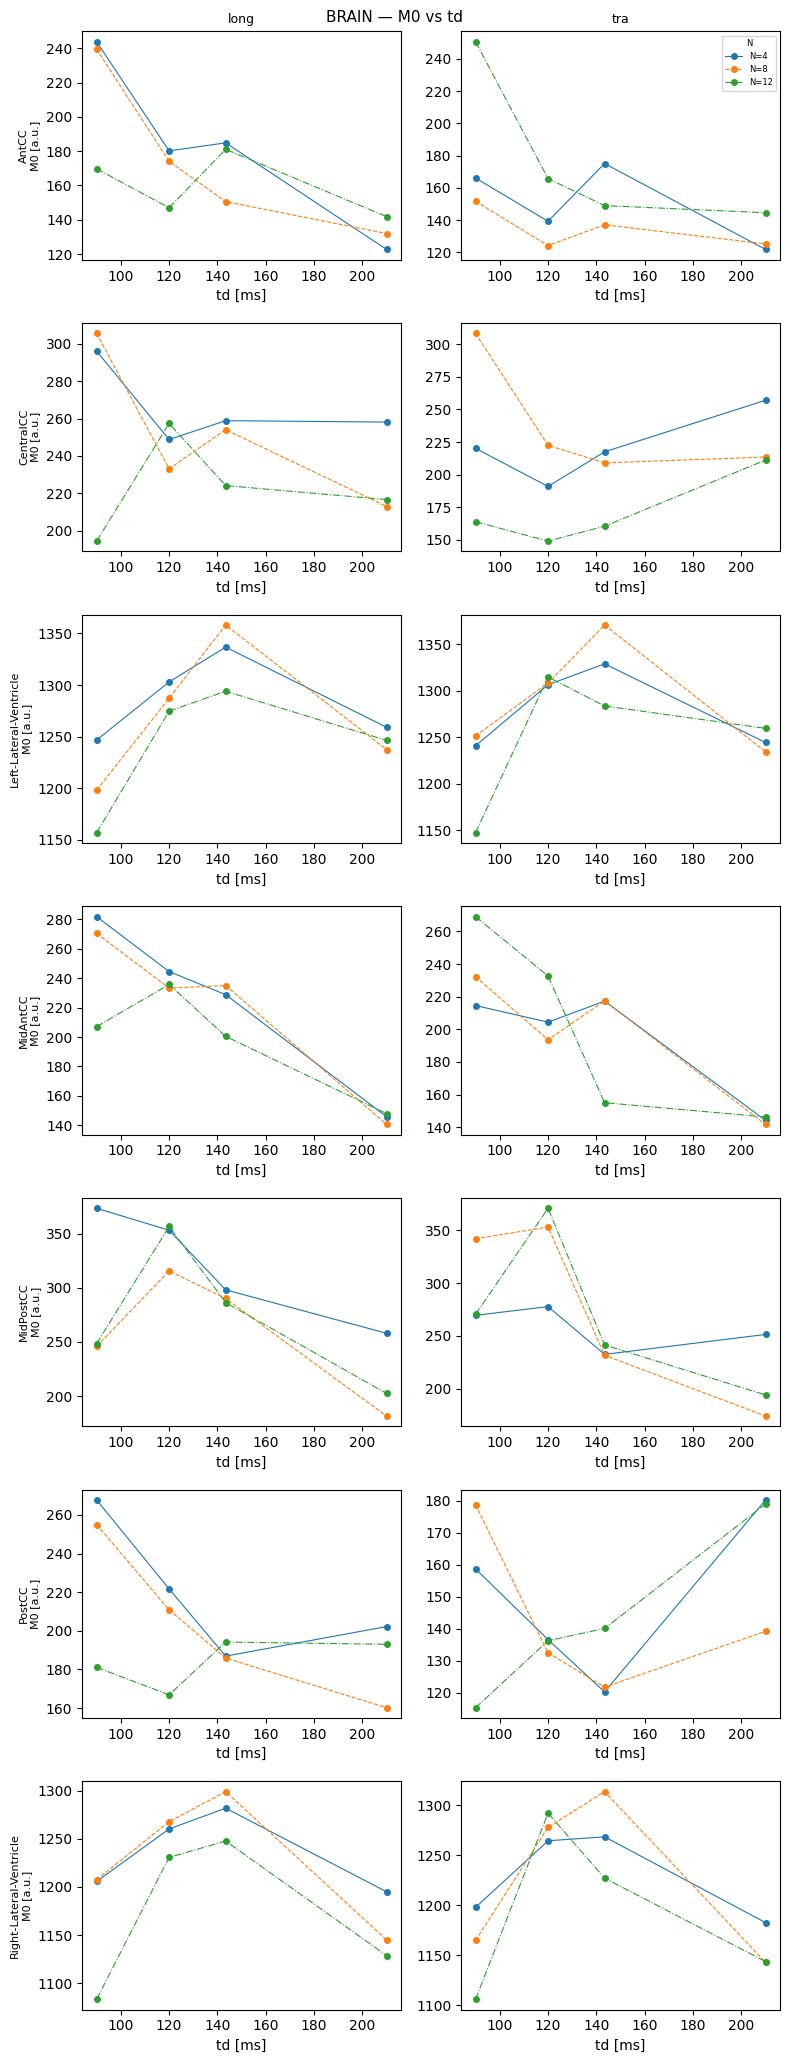

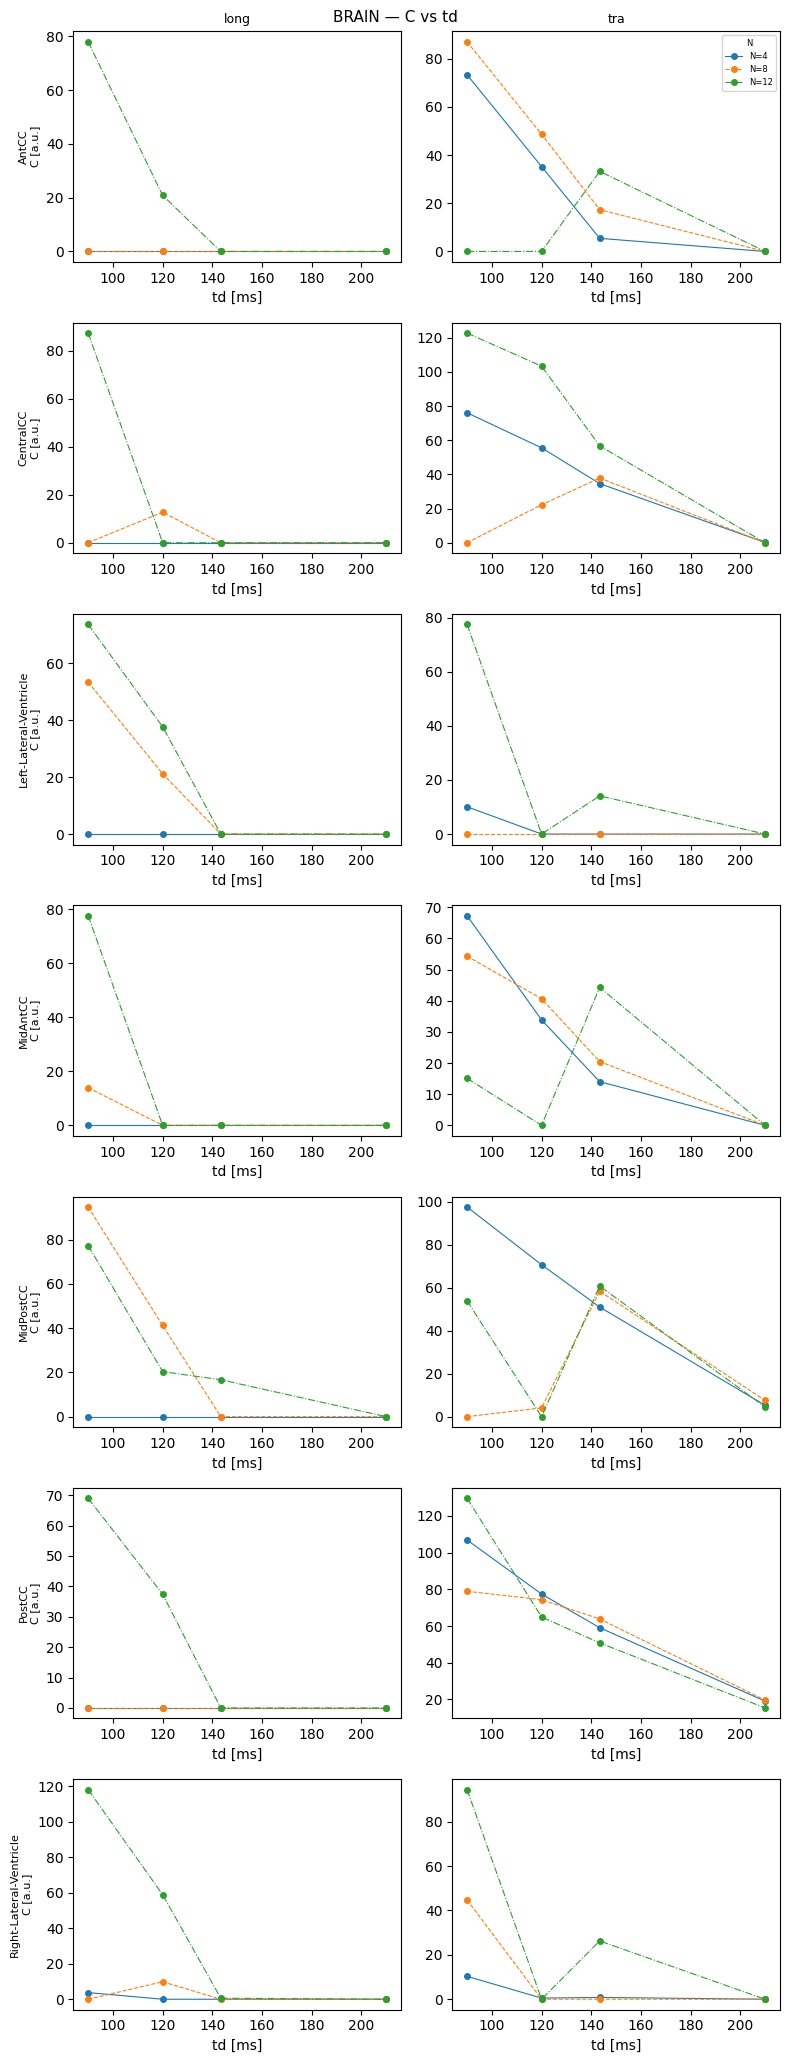

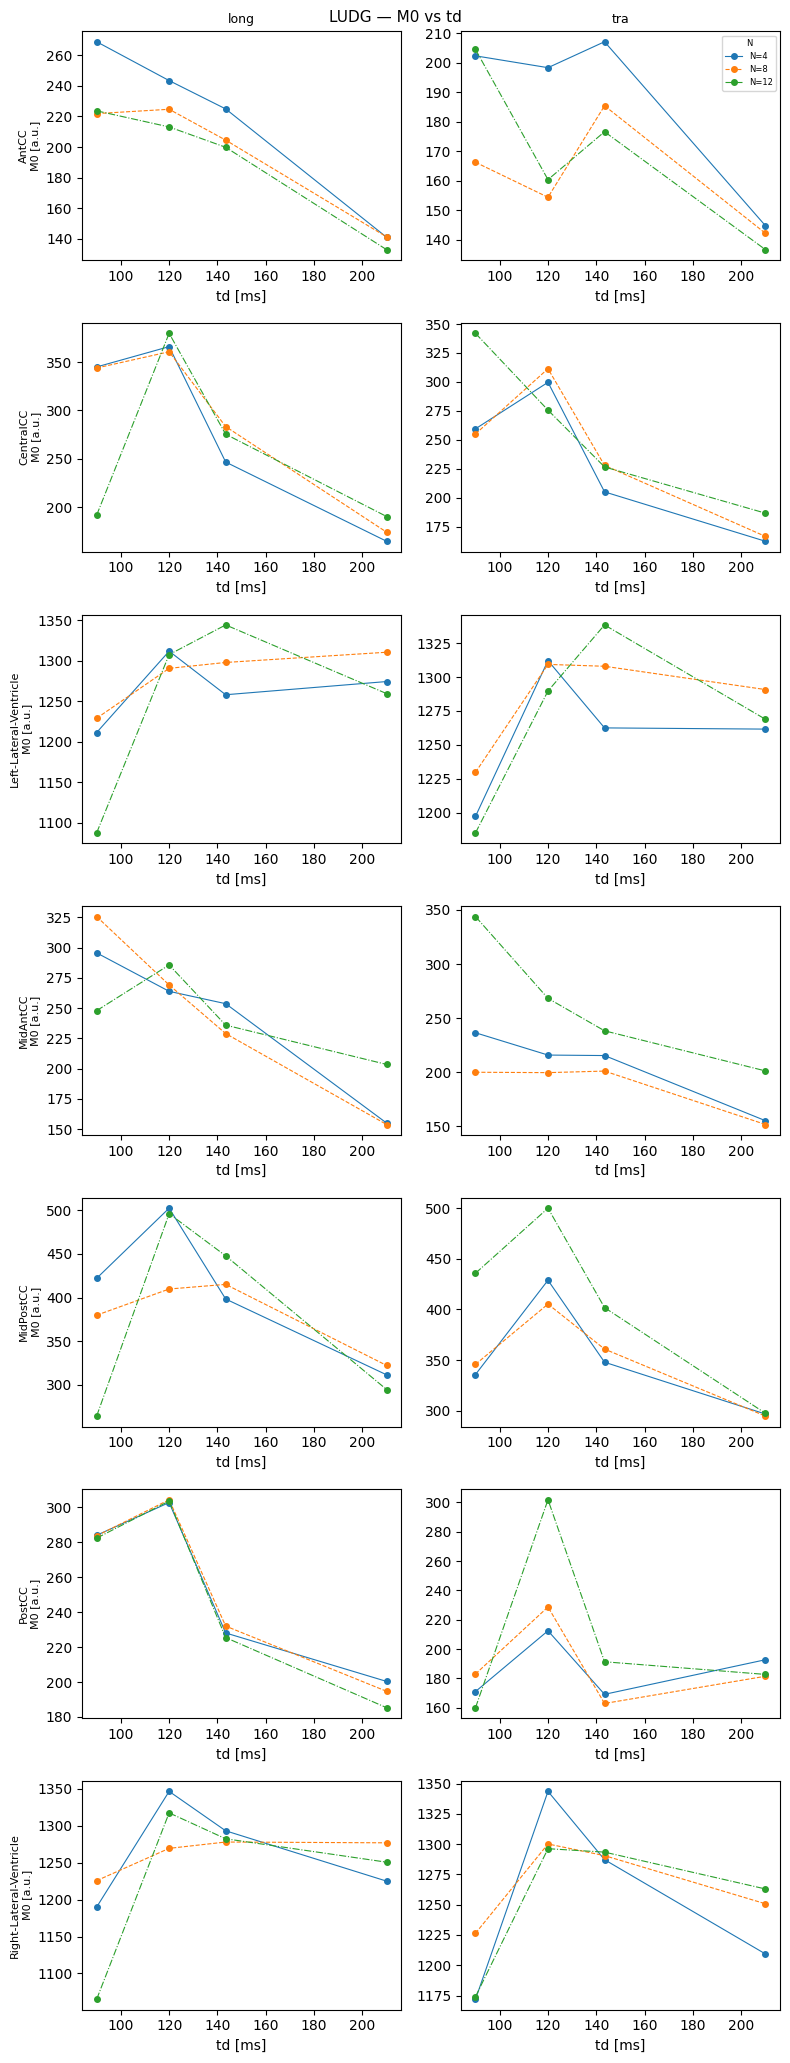

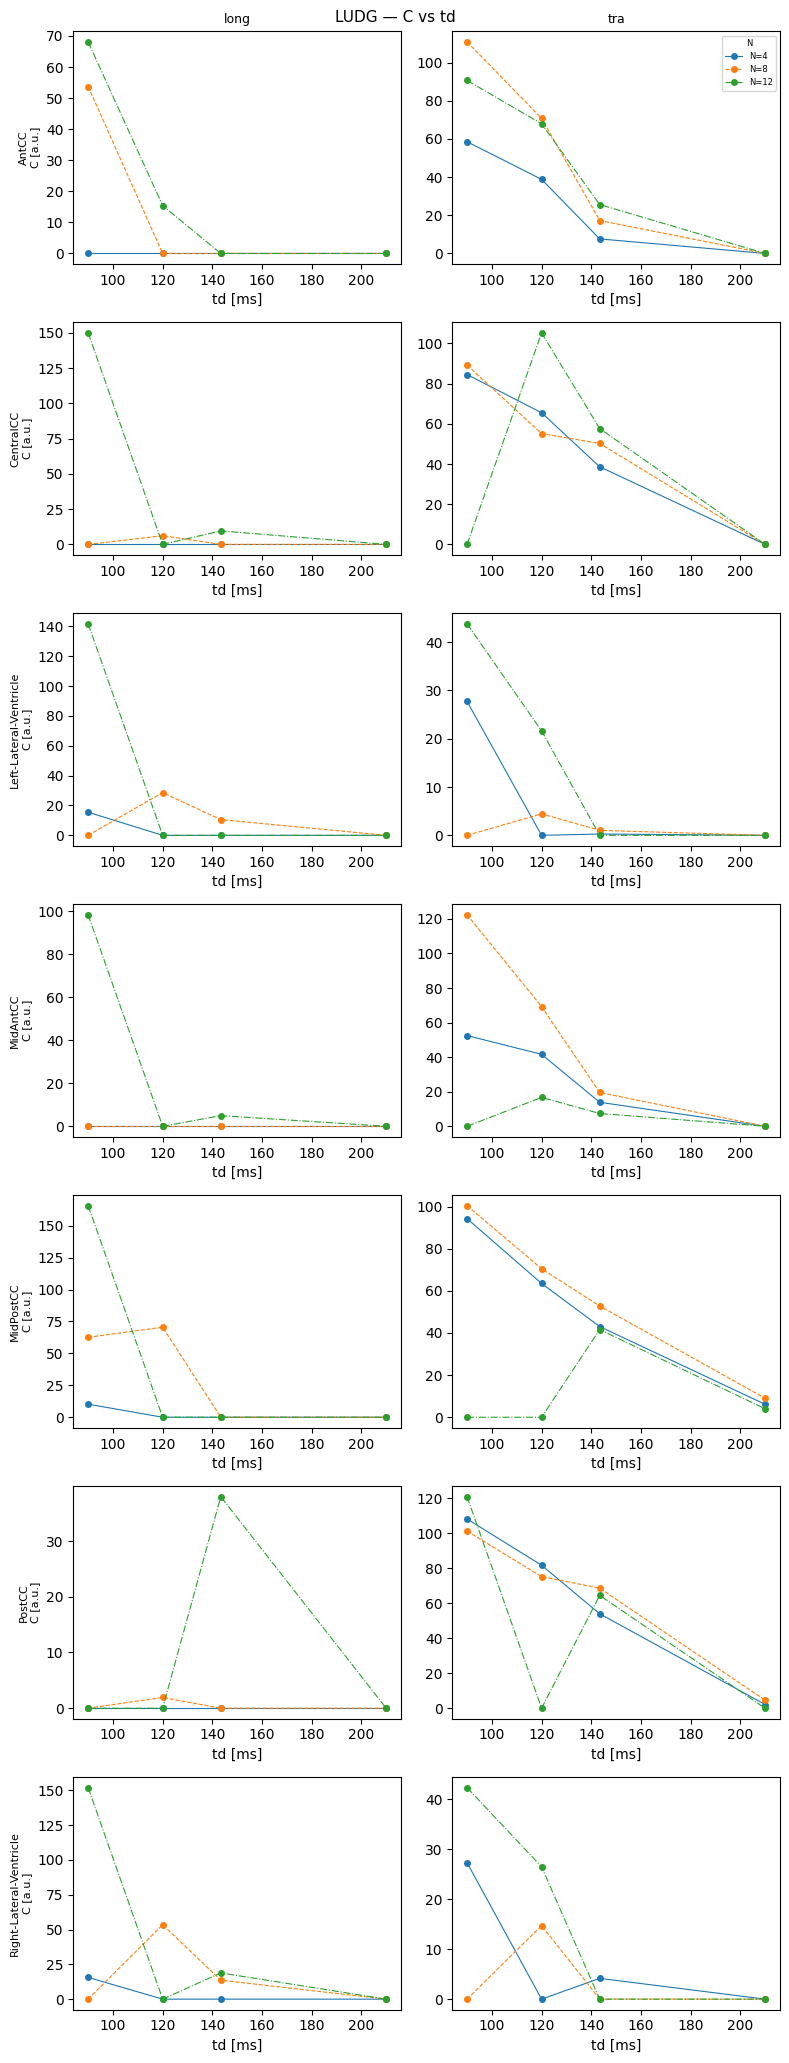

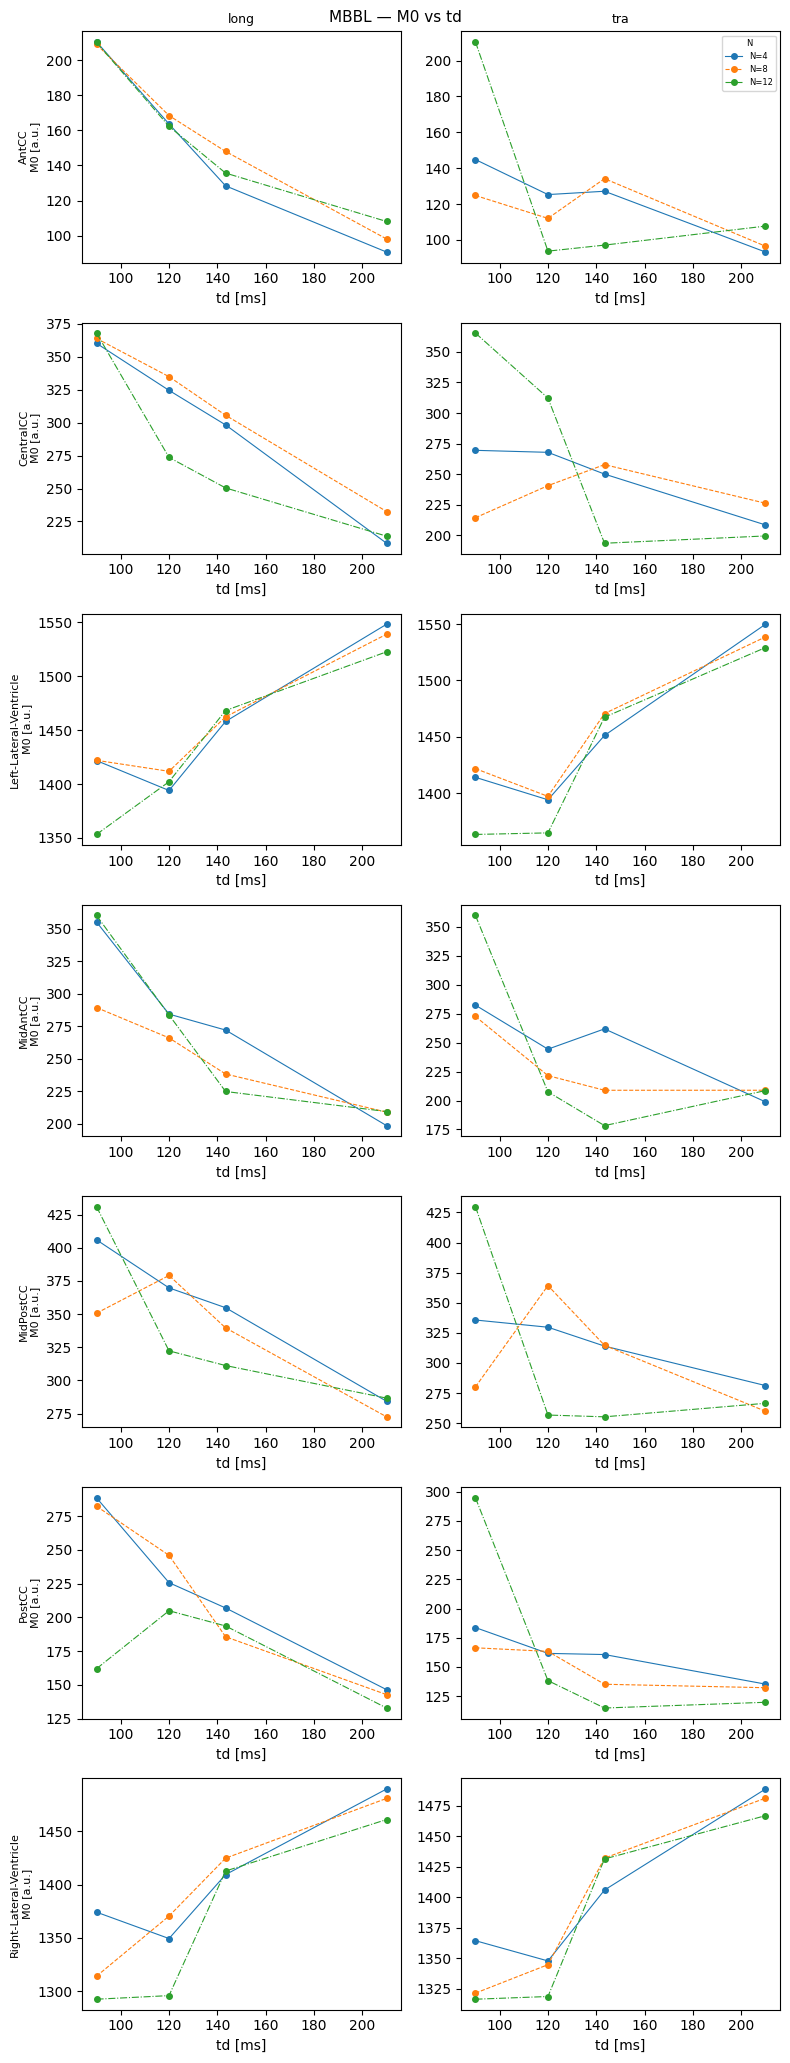

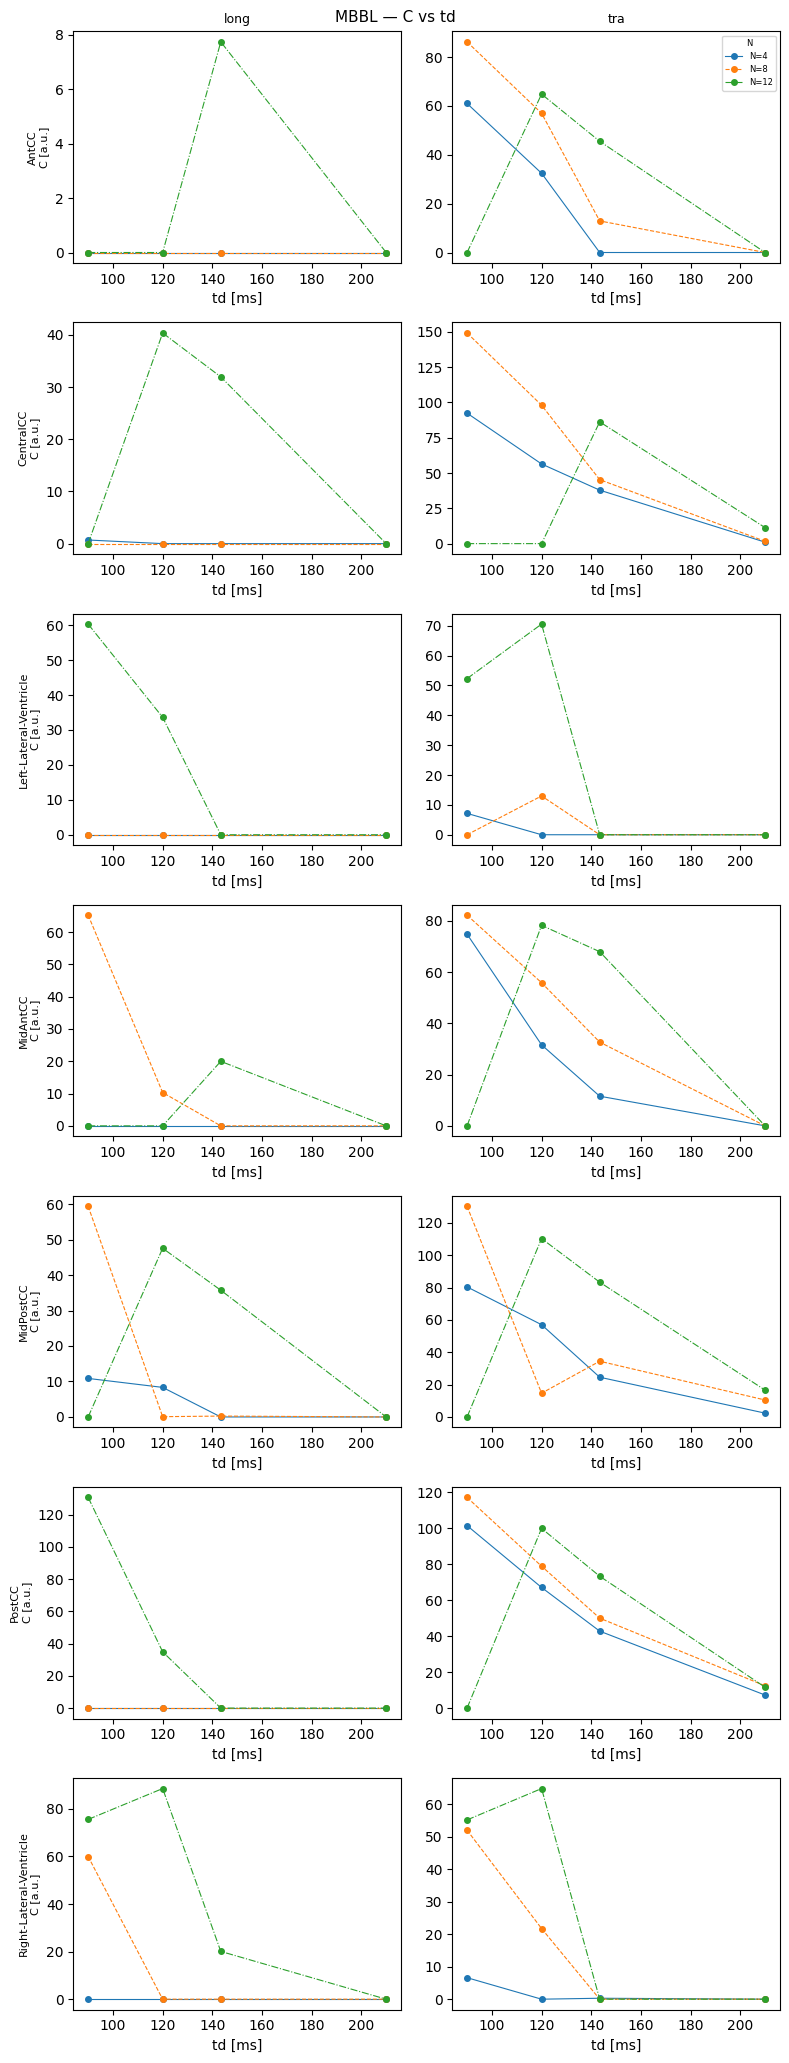

In [23]:
subjects_plot = sorted(results_df.subj.unique())
rois_plot     = sorted(results_df.roi.unique())
Ns_plot       = sorted(results_df.N.unique())
dirs_plot     = [d for d in ["long", "tra"] if d in results_df.direction.unique()]
roi_colors_p  = _roi_color_map(rois_plot)
_N_ls_p       = ["-", "--", "-.", ":"]
N_ls          = {N: _N_ls_p[i % len(_N_ls_p)] for i, N in enumerate(Ns_plot)}

for subj in subjects_plot:
    for param, ylabel in [("M0", "M0 [a.u.]"), ("C", "C [a.u.]")]:
        fig, axes = plt.subplots(
            len(rois_plot), len(dirs_plot),
            figsize=(4 * len(dirs_plot), 3 * len(rois_plot)),
            sharey=False, squeeze=False
        )
        for i_roi, roi in enumerate(rois_plot):
            for i_dir, direction in enumerate(dirs_plot):
                ax = axes[i_roi, i_dir]
                sub = results_df[
                    (results_df.subj == subj) &
                    (results_df.roi == roi) &
                    (results_df.direction == direction)
                ]
                for N in Ns_plot:
                    g = sub[sub.N == N].sort_values("td_ms")
                    if g.empty:
                        continue
                    ax.plot(g.td_ms, g[param], linestyle=N_ls[N],
                            marker="o", ms=4, linewidth=0.8, label=f"N={N}")
                if i_roi == 0:
                    ax.set_title(direction, fontsize=9)
                if i_dir == 0:
                    ax.set_ylabel(f"{roi}\n{ylabel}", fontsize=8)
                ax.set_xlabel("td [ms]")
                if i_roi == 0 and i_dir == len(dirs_plot) - 1:
                    ax.legend(fontsize=6, title="N", title_fontsize=6)
        fig.suptitle(f"{subj} — {param} vs td", fontsize=11)
        fig.tight_layout()
        fig.savefig(OUT_DIR / f"{param}_vs_td_{subj}.png", dpi=120)
        # plt.show()

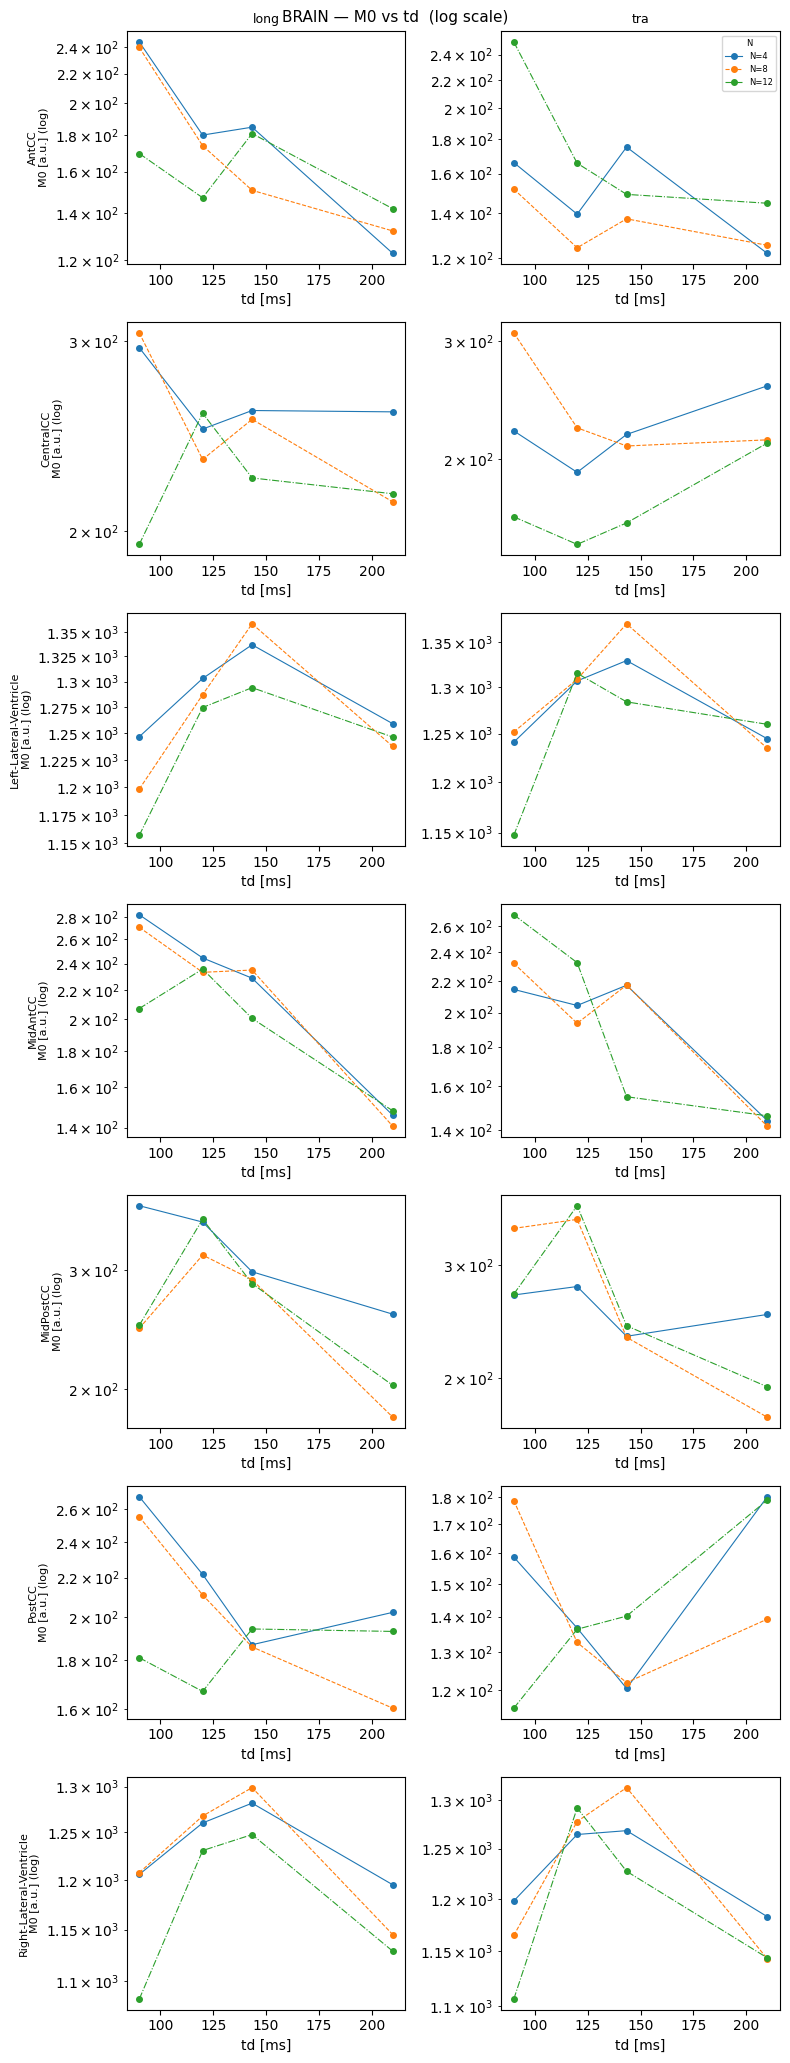

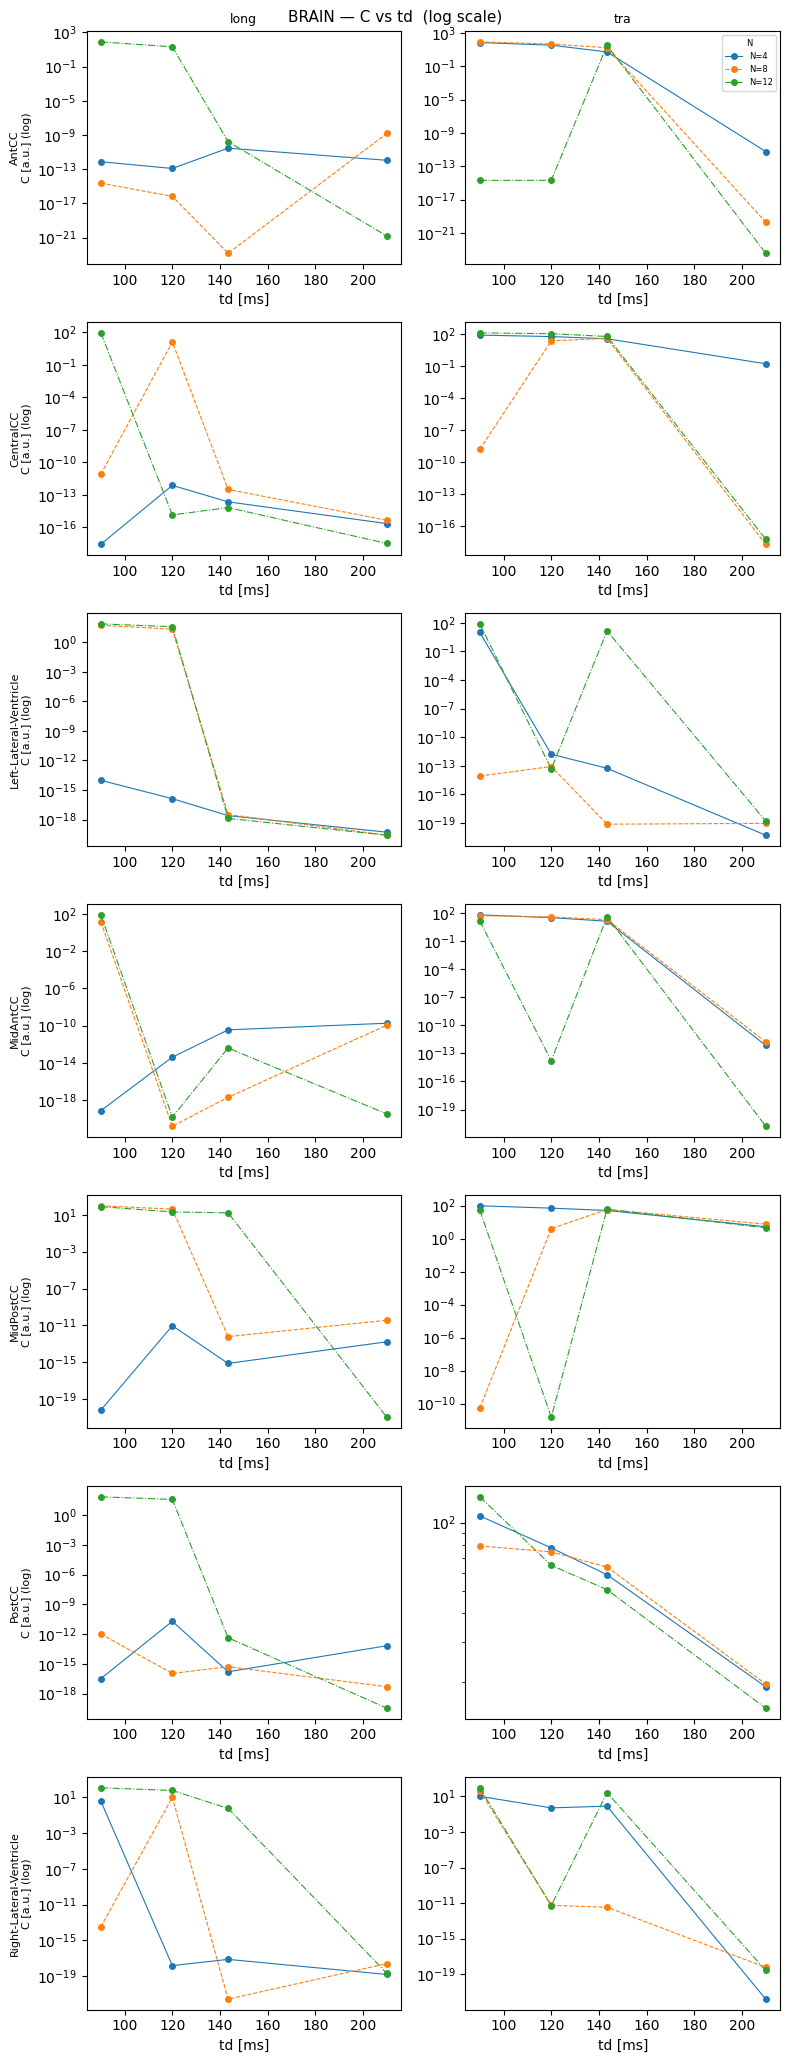

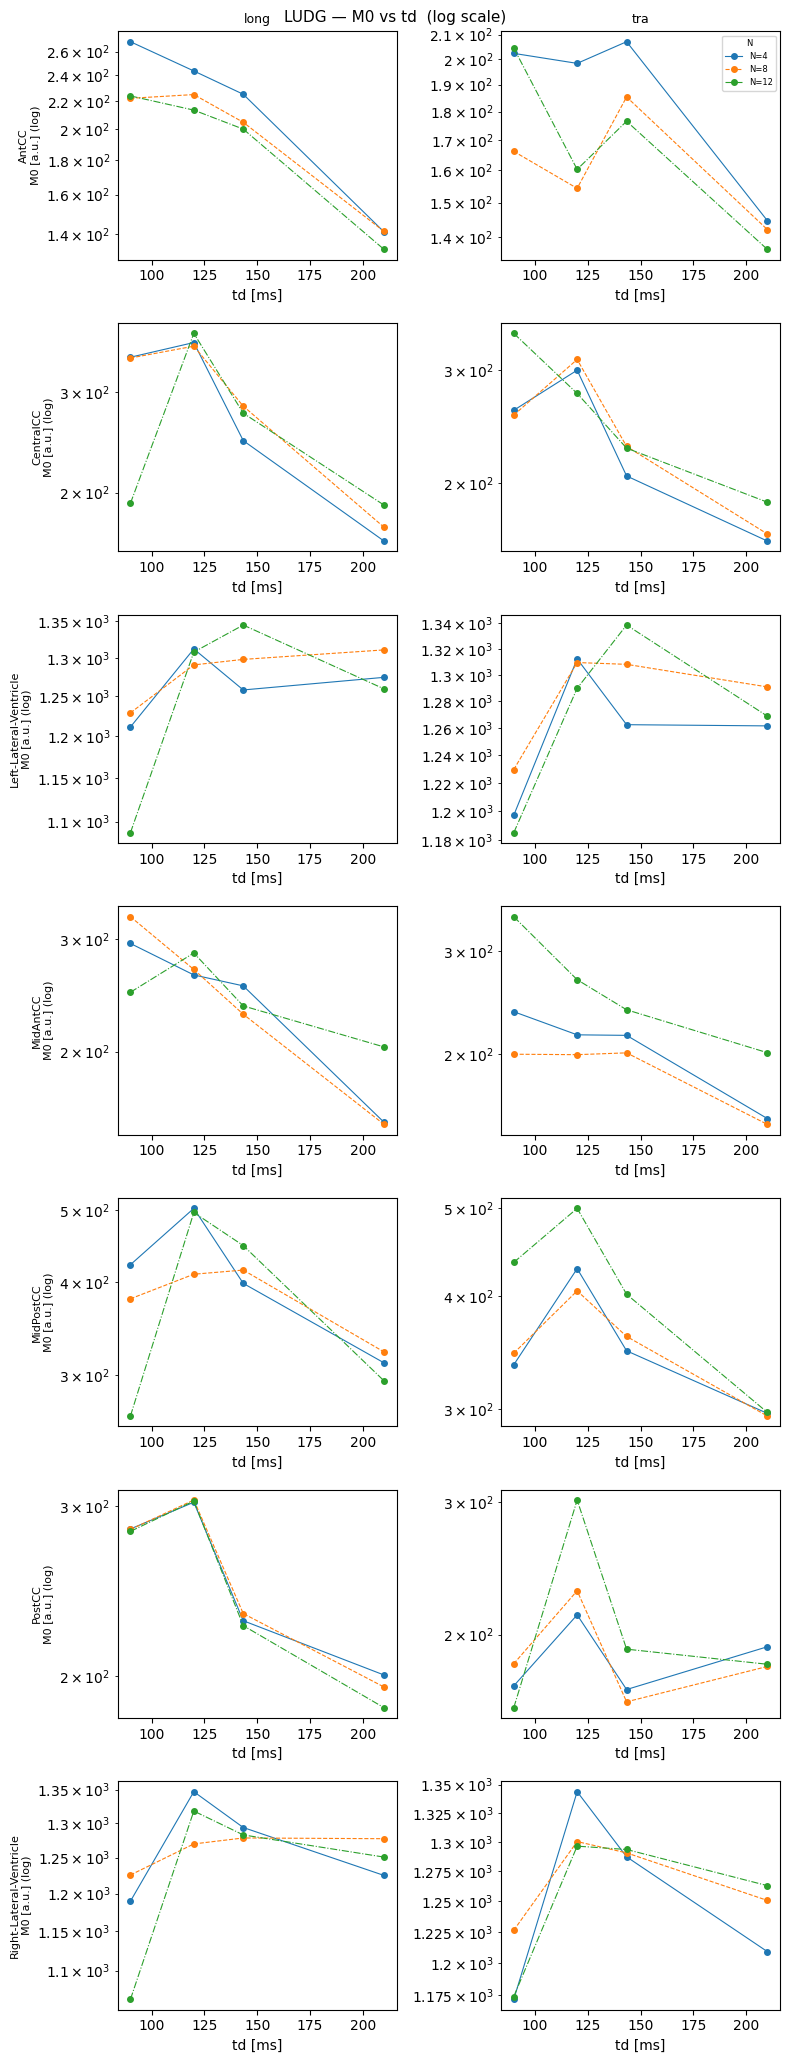

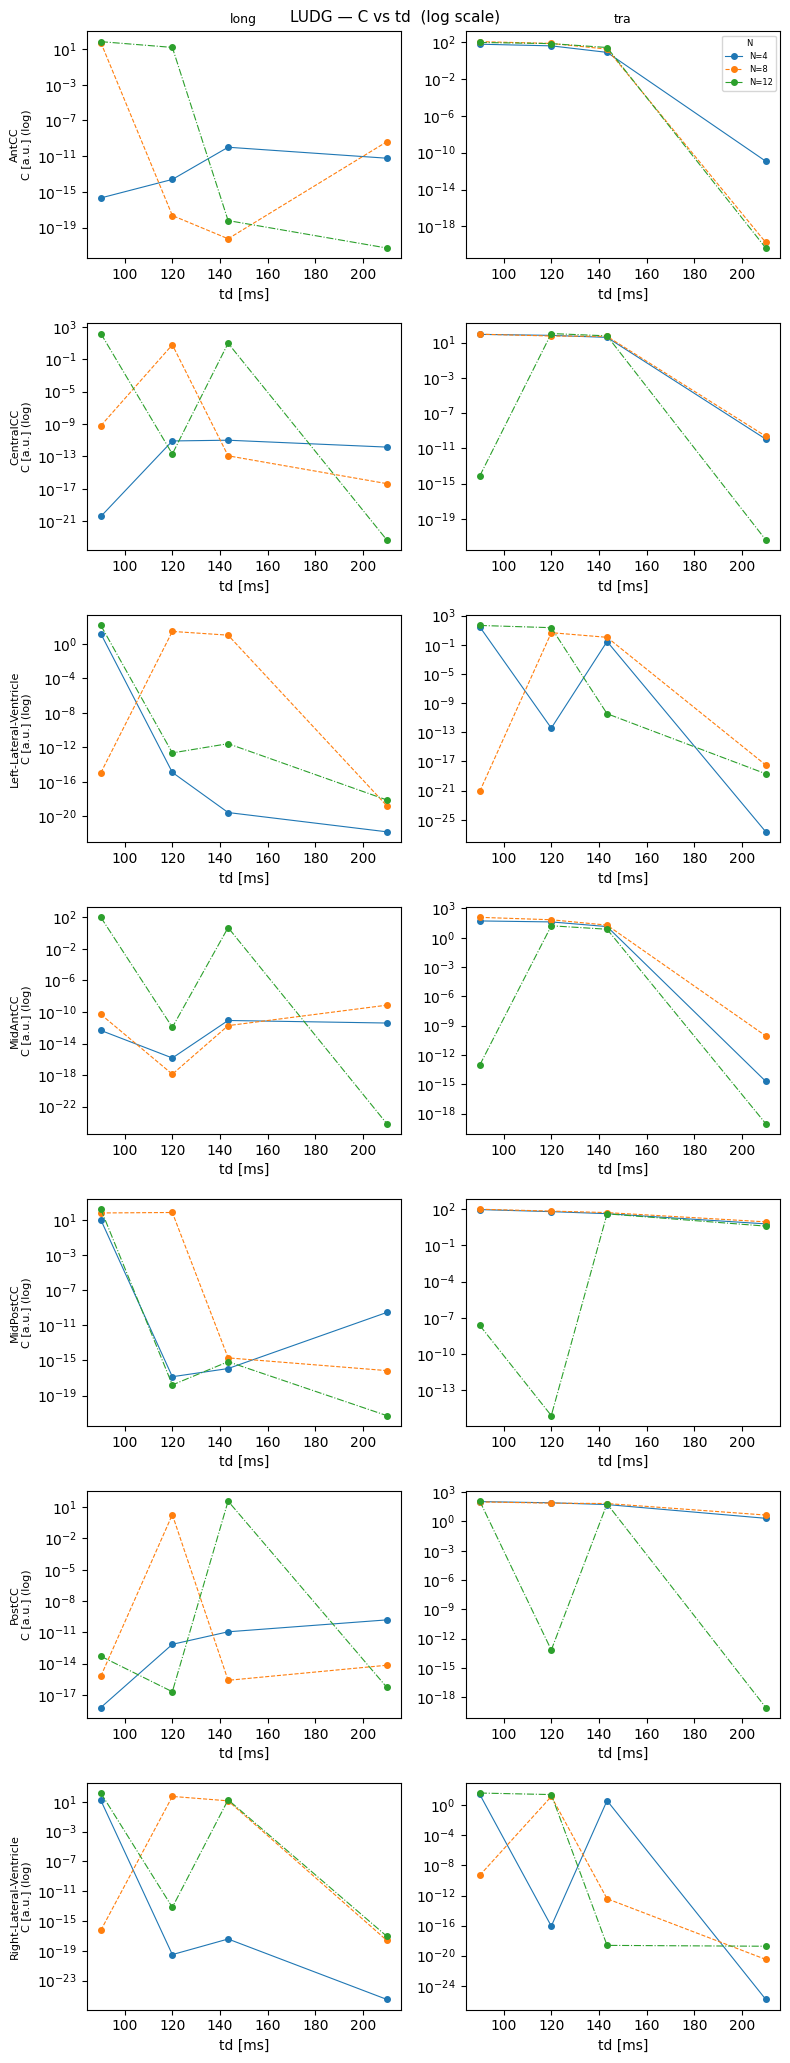

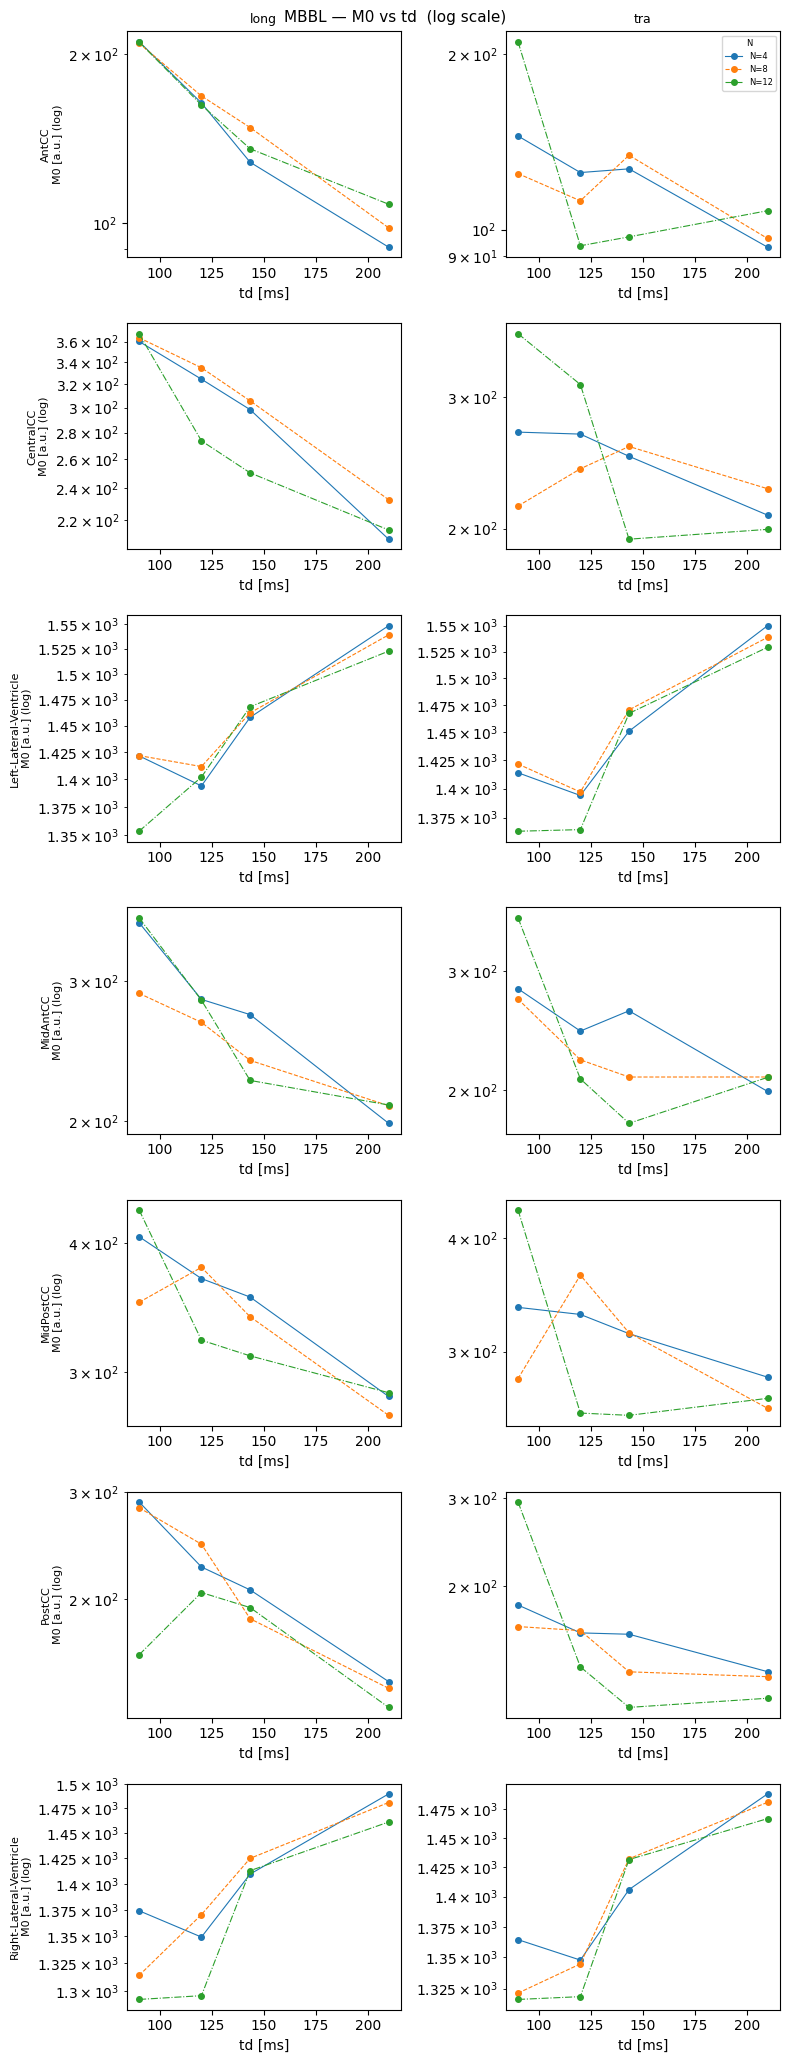

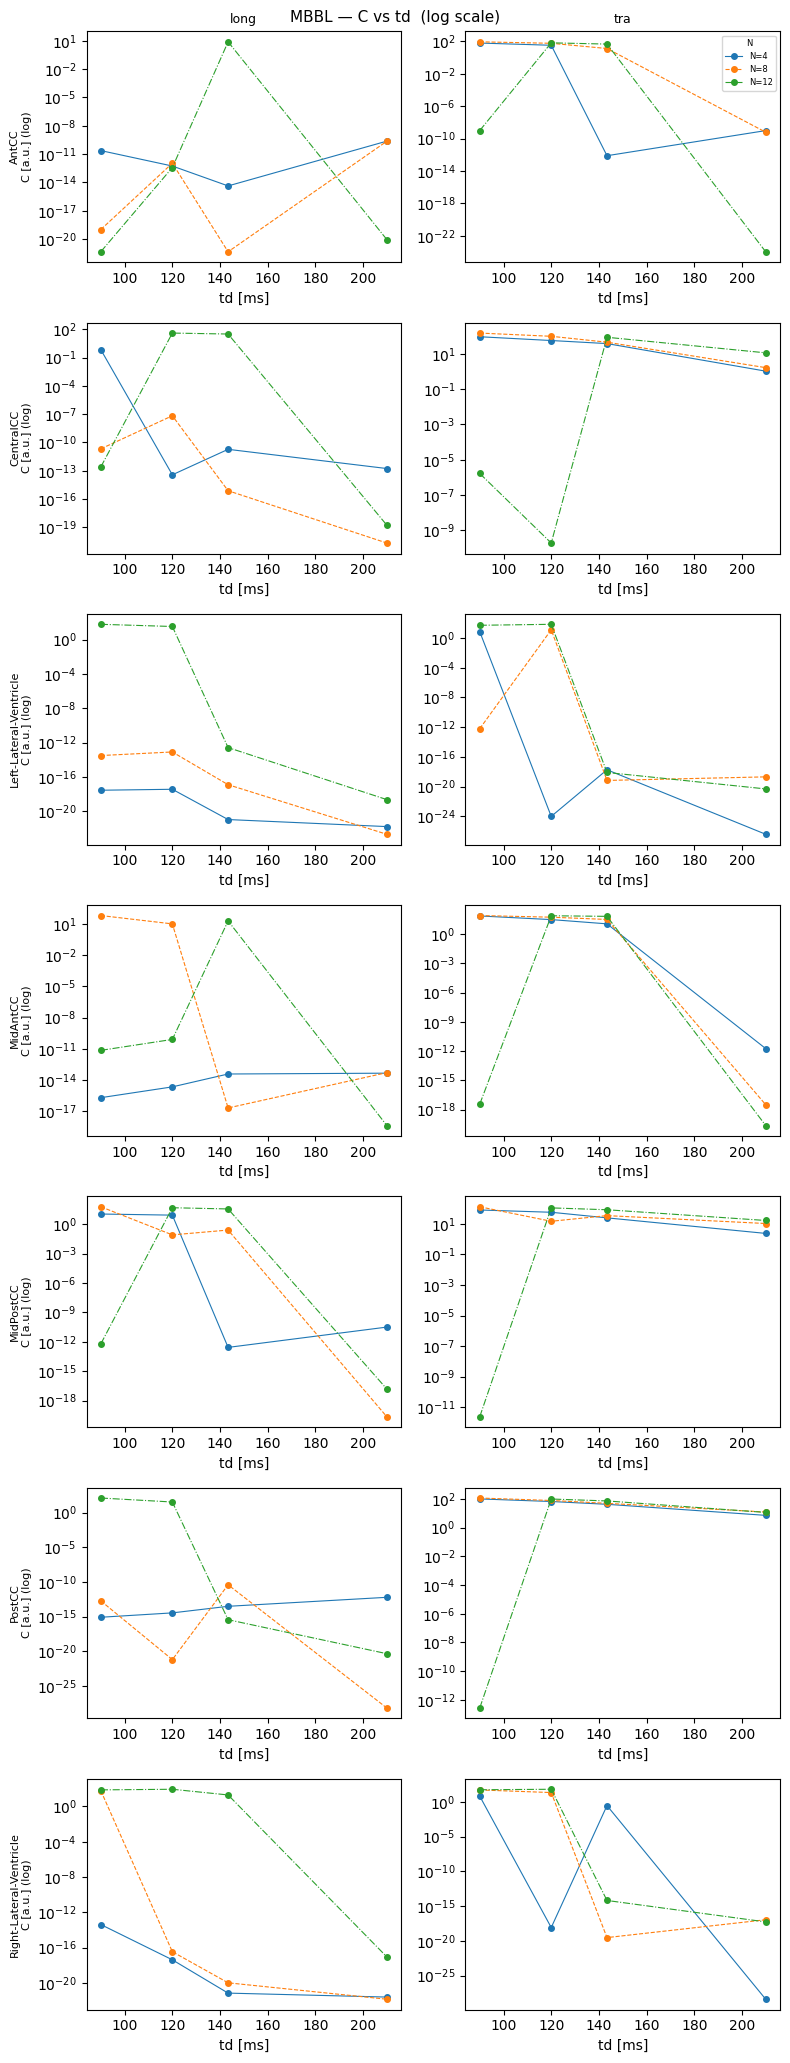

In [ ]:
for subj in subjects_plot:
    for param, ylabel in [("M0", "M0 [a.u.]"), ("C", "C [a.u.]")]:
        fig, axes = plt.subplots(
            len(rois_plot), len(dirs_plot),
            figsize=(4 * len(dirs_plot), 3 * len(rois_plot)),
            sharey=False, squeeze=False
        )
        for i_roi, roi in enumerate(rois_plot):
            for i_dir, direction in enumerate(dirs_plot):
                ax = axes[i_roi, i_dir]
                sub = results_df[
                    (results_df.subj == subj) &
                    (results_df.roi == roi) &
                    (results_df.direction == direction)
                ]
                for N in Ns_plot:
                    g = sub[sub.N == N].sort_values("td_ms")
                    if g.empty:
                        continue
                    ax.plot(g.td_ms, g[param], linestyle=N_ls[N],
                            marker="o", ms=4, linewidth=0.8, label=f"N={N}")
                ax.set_yscale("log")
                if i_roi == 0:
                    ax.set_title(direction, fontsize=9)
                if i_dir == 0:
                    ax.set_ylabel(f"{roi}\n{ylabel} (log)", fontsize=8)
                ax.set_xlabel("td [ms]")
                if i_roi == 0 and i_dir == len(dirs_plot) - 1:
                    ax.legend(fontsize=6, title="N", title_fontsize=6)
        fig.suptitle(f"{subj} — {param} vs td  (log scale)", fontsize=11)
        fig.tight_layout()
        fig.savefig(OUT_DIR / f"{param}_vs_td_log_{subj}.png", dpi=120)
        # plt.show()